# Support vector machines

In [1]:
import numpy as np
import sklearn

## Maximum-margin classification

A support vector machine (SVM) is a classifier that searches for the *decision boundary that separates the classes by the largest possible margin*. For linearly separable data with labels $y_i \in \{-1, +1\}$, the boundary is the hyperplane $\boldsymbol{w}^\top \boldsymbol{x} + b = 0$ that maximizes the margin while still classifying every training point correctly,

(eq:svm_margin)=
$$
\min_{\boldsymbol{w}, b} \ \tfrac{1}{2}\lVert \boldsymbol{w} \rVert^2
\quad \text{subject to} \quad
y_i \left( \boldsymbol{w}^\top \boldsymbol{x}_i + b \right) \ge 1 \ \ \forall i
$$

The support vectors are the training samples closest to the decision boundary. They "support" the position of the boundary because moving or removing them changes the solution, whereas most other training samples have little influence.

:::{image} attachment:7dd79b61-da86-4c8c-96f6-5d89b38ffefc.png
:width: 30%
:align: center
:::
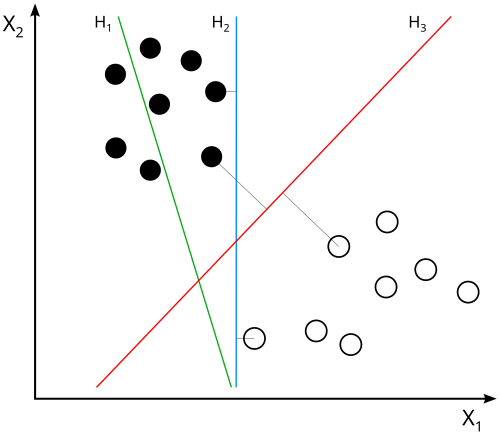

### Soft margin

Real data is rarely perfectly separable, so a *soft-margin* version introduces slack variables, controlled by a regularization parameter $C$: a small $C$ allows more margin violations (a smoother boundary, less overfitting), while a large $C$ penalizes violations heavily (a tighter fit to the training data).

### Kernel trick

Many data sets are not linearly separable in their original feature space. The *kernel trick* implicitly maps the data into a higher-dimensional space where a linear separation becomes possible, without ever computing the mapping $\phi(\boldsymbol{x})$ explicitly — only the kernel (inner product in the new space) is needed,

(eq:svm_kernel)=
$$
k(\boldsymbol{x}_i, \boldsymbol{x}_j) = \phi(\boldsymbol{x}_i)^\top \phi(\boldsymbol{x}_j)
$$

The kernel function can be interpreted as a similarity measure between two samples. Large kernel values indicate that the samples are similar, while small values indicate that they are dissimilar.

**Practical recommendations for the RBF kernel**

A common nonlinear choice is the RBF kernel:

(eq:svm_rbf)=
$$
k(\boldsymbol{x}_i, \boldsymbol{x}_j) = \exp(-\gamma \lVert \boldsymbol{x}_i - \boldsymbol{x}_j \rVert^2)
$$

The RBF kernel is often a good default choice when there is no strong reason to assume that the classes can be separated linearly. Two hyperparameters must be selected: the regularization parameter $C$ and the kernel parameter $\gamma$. The parameter $\gamma$ controls the radius of influence of each training sample. Small values of $\gamma$ produce smooth decision boundaries and may lead to underfitting, while large values create highly localized decision boundaries that can lead to overfitting. The parameter $C$ controls the penalty for classification errors. Small values of $C$ allow a wider margin at the expense of more classification errors, whereas large values of $C$ attempt to classify all training samples correctly and may overfit the data.

As a practical starting point, it is often reasonable to use `gamma="scale"` (the default in `scikit-learn`) and $C=1$, which sets $\gamma$ equal to

$$
\gamma = \frac{1}{N_\mathrm{features} \mathrm{Var}(X)}
$$

where $\mathrm{Var}(X)$ is the variance of the entire feature matrix ($X$ is flattened before the calculation of the variance).

Model selection can then be performed using cross-validation over a logarithmic grid such as

- $C \in \{0.01, 0.1, 1, 10, 100\}$
- $\gamma \in \{0.001, 0.01, 0.1, 1, 10\}$

A useful rule of thumb is:

- Poor performance on both training and validation data suggests increasing $C$ or $\gamma$.
- Excellent training performance but poor validation performance suggests decreasing $C$ or $\gamma$.
- Standardizing the input features before training is typically essential, since the RBF kernel depends directly on distances between data points.

| Kernel | Mathematical form | Typical use | Advantages | Limitations |
|:--------|:-----------------|:------------|:------------|:------------|
| Linear | $k(\mathbf{x}_1,\mathbf{x}_2) = \mathbf{x}_1^\top \mathbf{x}_2$ | High-dimensional data, text data, linearly separable problems | Fast, easy to interpret, few hyperparameters | Cannot model strongly nonlinear relationships |
| Polynomial | $k(\mathbf{x}_1,\mathbf{x}_2) = (\gamma\,\mathbf{x}_1^\top\mathbf{x}_2 + r)^d$ | Problems where interactions between features are important | Can model curved decision boundaries | Parameter tuning can be difficult; computationally expensive for high degrees |
| RBF (Gaussian) | $k(\mathbf{x}_1,\mathbf{x}_2) = \exp(-\gamma \lVert \mathbf{x}_1-\mathbf{x}_2\rVert^2)$ | General-purpose nonlinear classification and regression | Usually a strong default choice; very flexible | Sensitive to the choice of $\gamma$ and $C$ |
| Sigmoid | $k(\mathbf{x}_1,\mathbf{x}_2) = \tanh(\gamma\,\mathbf{x}_1^\top\mathbf{x}_2 + r)$ | Historically inspired by neural networks | Can model nonlinear relationships | Less commonly used; often outperformed by RBF |
| Precomputed | User-supplied kernel matrix | Domain-specific similarity measures | Allows custom notions of similarity | Requires construction and storage of the kernel matrix |

## Example of binary classification

### Data preparation

We use the **breast cancer** data set containing 569 samples with 30 features from digitized FNA biopsy images, and a binary diagnosis (malignant/benign). All 30 features are standardized, since the SVM's margin, Eq. {eq}`eq:svm_margin`, and the RBF kernel, Eq. {eq}`eq:svm_kernel`, both depend on Euclidean distances and are sensitive to feature scale.

In [2]:
cancer = sklearn.datasets.load_breast_cancer()
X, y = cancer.data, cancer.target

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=0,
)

scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model definition

We fit an SVM with an RBF kernel, Eq. {eq}`eq:svm_rbf`, using all 30 features. The regularization parameter `C` and the kernel width `gamma` are the two main hyperparameters to tune.

In [3]:
svm = sklearn.svm.SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
)

### Model training

In [4]:
svm.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Decision boundary

With 30 features we cannot plot the decision boundary directly, so in order to visualize *how* the RBF kernel separates the two diagnoses, we project the (scaled) training data onto its first two [principal components](pca.ipynb) and project the 2D mesh into the 30D feature space, where it is correctly evaluated by the SVM.

In [5]:
pca = sklearn.decomposition.PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train_scaled)

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300),
)

# map the 2D grid back into the original 30D (scaled) feature space,
# then evaluate the ACTUAL trained SVM there
grid_2d = np.c_[xx.ravel(), yy.ravel()]
grid_high_d = pca.inverse_transform(grid_2d)
Z = svm.decision_function(grid_high_d).reshape(xx.shape)

# project the real support vectors into the same 2D view for reference
support_vectors_2d = pca.transform(svm.support_vectors_)

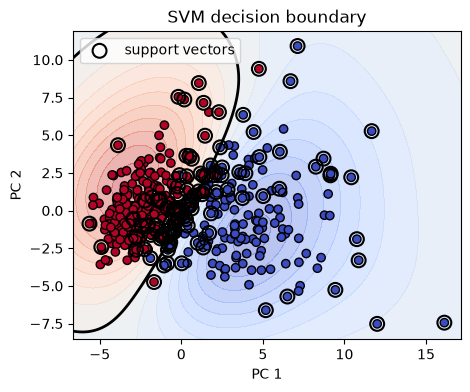

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, levels=20, cmap=plt.cm.coolwarm, alpha=0.4)
plt.contour(xx, yy, Z, levels=[0], colors="k", linewidths=2)
plt.scatter(
    X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=plt.cm.coolwarm, edgecolor="k"
)
plt.scatter(
    support_vectors_2d[:, 0],
    support_vectors_2d[:, 1],
    facecolors="none",
    edgecolors="black",
    s=100,
    linewidths=1.5,
    label="support vectors",
)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend()
plt.title("SVM decision boundary")
plt.show()

Note that the support vectors are not exactly located on the decision boundaries, which is due to loss of information during the PCA projection from 30D into 2D.

## Model evaluation

In [7]:
y_pred = svm.predict(X_test_scaled)

print(
    sklearn.metrics.classification_report(
        y_test, y_pred, target_names=cancer.target_names
    )
)

              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



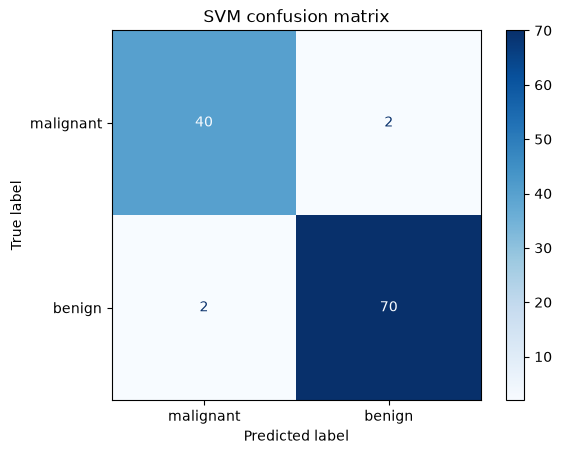

In [8]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

disp = sklearn.metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=cancer.target_names
)
disp.plot(cmap=plt.cm.Blues)

plt.title("SVM confusion matrix")

plt.show()

SVMs introduce relatively few parameters: the number of hyperplanes dividing the different possible classes (only 1 for binary classification) times the number of input features (in this case 30) and adding a bias coefficient. In addition, the influence of the support vectors must also be stored. But, even so, the number of trainable parameters is typically much smaller than in a neural network.

In [9]:
print(f"Number of parameters: {np.prod(svm._get_coef().shape) + len(svm.intercept_)}")

Number of parameters: 31


## Take-away

- SVMs are a strong choice with limited resources: they tend to work well even with relatively few training samples and many features, are convex (a single global optimum, no random initialization issues), and the kernel trick gives flexible, nonlinear decision boundaries without manual feature engineering.
- The main practical cost is that training scales poorly to large data sets (typically beyond tens of thousands of samples for the kernelized version).